
<h1> <center> TP Classification supervisée </center> </h1>

<center>Auteur : Christel Vrain - Université d'Orléans </center>
Ces supports sont issus du cours de Christel Vrain et ont été réédités par Anaïs Halftermeyer



# Classification supervisée avec Scikit-Learn





Nous allons utiliser la libraire **sci-kit learn** (voir http://scikit-learn.org/stable/)

Nous aurons aussi besoin des librairies **numpy** (librairie pour le calcul scientifique, voir http://www.numpy.org/), **pandas** (librairie pour la manipulation de structures de données et l'analyse de données, voir https://pandas.pydata.org/ et **matplotlib** (librairie pour la visualisation de données, voir https://matplotlib.org/).

Un bon ouvrage d'introduction à ces 4 librairies: *Python Data Science Handbook* par Jake VanderPlas, edition O'Reilly https://jakevdp.github.io/PythonDataScienceHandbook/.

Avant de commencer, vous pouvez

- compléter un appel de fonction avec la touche TAB qui vous donnera les différents choix possibles,

- avoir de l'information sur une fonction en la terminant par un ?


## Base de données

Dans **scikit-learn**, quelques bases de données jouets (*iris*, *diabetes*,*wine*, *breast_cancer*) sont déjà incluses. Elles sont déjà découpées (via un dictionnaire) en un tableau de données (*data*) décrivant les variables explicatives et un tableau (*target*) donnant la variable prédictive ou variable cible. En général, lorsque l'on charge une base de données elle a toutes les variables et il faudra la découper en une matrice contenant les variables explicatives et un tableau contenant la variable explicative. Pour ce faire, on peut soit utiliser des tableaux **numpy** ou des dataframes définies dans le module **pandas**. Dans ce TP,  nous nous appuyons sur les bases de données définies dans **scikit-learn**


Chargeons une base : digit

In [2]:
from sklearn import datasets
digits=datasets.load_digits()
X_digits = digits.data
y_digits = digits.target

La base de données obtenue est sous la forme d'un dictionnaire avec au moins deux éléments:
- data: clef indexant le tableau de données de taille  (n_samples, n_features) (variable explicative)
- target: clef indexant le tableau de données cibles de taille  (n_samples * 1) (variable
- DESCR: une description
- feature_names, target_names: noms des variables explicatives et de la variable cible

Les tableaux de données obtenus avec *data* et *target* sont de type *numpy.ndarray*

In [3]:
import numpy as np
a=np.array([1,2,3])

In [4]:
a

array([1, 2, 3])

In [5]:
len(a)

3

In [6]:
np.shape(a)

(3,)

In [7]:
a[0]

np.int64(1)

In [8]:
a[0:2]

array([1, 2])

In [9]:
a[a>2]

array([3])

In [10]:
b=np.array([[1,2,3,4,5],[6,7,8,9,10]])
b

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10]])

In [11]:
len(b)

2

In [12]:
# 2ème ligne
b[1,:]

array([ 6,  7,  8,  9, 10])

In [13]:
# 4ème colonne
b[:,3]

array([4, 9])

In [14]:
type(X_digits)

numpy.ndarray

In [15]:
#taille de la matrice des données
X_digits.shape

(1797, 64)

In [16]:
#type y_digits
type(y_digits)

numpy.ndarray

In [17]:
#taille de la liste (tableau) des étiquettes
digits.target.shape

(1797,)

In [18]:
y_digits

array([0, 1, 2, ..., 8, 9, 8], shape=(1797,))

**Standardisation des données**


Afficher la 3ème colonne de X_digits. Calculer sa moyenne et sa variance

In [19]:
X_digits[:,2]

array([ 5.,  0.,  0., ...,  1.,  2., 10.], shape=(1797,))

In [20]:
np.mean(X_digits[:,2])

np.float64(5.204785754034502)

In [21]:
np.var(X_digits[:,2])

np.float64(22.595792344193274)

In [22]:
from sklearn.preprocessing import scale
# normalisation des données
X_digits=scale(X_digits)
# axis = 0 signifie que la variance est calculée sur chaque colonne
X_digits.var(axis=0)
# On voit que des variables ont une variance nulle, comme par exemple la 1ère variable (d'indice 0).
# On peut le vérifier en faisant afficher la 1ère colonne X_digits[:,0]
# On pourrait supprimer cette colonne np.delete(X_digits,0,axis=0).

array([0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [23]:
X_digits[:,0]

array([0., 0., 0., ..., 0., 0., 0.], shape=(1797,))

### Exercice :
Chargez la base de données *iris*.
Affichez sa description.
Affichez la taille de la base de données et la taille de la cible.
Stockez les données dans X_iris et les étiquettes dans y_iris.
Affichez la 1ère ligne de X_iris et la 1ère colonne.

In [41]:
from sklearn import datasets

#✍   Chargez la base de données iris
iris = datasets.load_iris()

#✍  Affichez sa description
#print(iris.DESCR)

#✍  Affichez la taille de la base de données et la taille de la cible
# nombre d'instances, nombre de label
print(iris.data.shape)
# nombre d'instances
print(iris.target.shape)

#✍  Stockez les données dans X_iris et les étiquettes dans y_iris
X_iris = iris.data
Y_iris = iris.target

#✍  Affichez la 1ère ligne de X_iris
print(X_iris[0])

#✍  Affichez la 1ère colonne de X_iris
print(X_iris[:,0])


(150, 4)
(150,)
[5.1 3.5 1.4 0.2]
[5.1 4.9 4.7 4.6 5.  5.4 4.6 5.  4.4 4.9 5.4 4.8 4.8 4.3 5.8 5.7 5.4 5.1
 5.7 5.1 5.4 5.1 4.6 5.1 4.8 5.  5.  5.2 5.2 4.7 4.8 5.4 5.2 5.5 4.9 5.
 5.5 4.9 4.4 5.1 5.  4.5 4.4 5.  5.1 4.8 5.1 4.6 5.3 5.  7.  6.4 6.9 5.5
 6.5 5.7 6.3 4.9 6.6 5.2 5.  5.9 6.  6.1 5.6 6.7 5.6 5.8 6.2 5.6 5.9 6.1
 6.3 6.1 6.4 6.6 6.8 6.7 6.  5.7 5.5 5.5 5.8 6.  5.4 6.  6.7 6.3 5.6 5.5
 5.5 6.1 5.8 5.  5.6 5.7 5.7 6.2 5.1 5.7 6.3 5.8 7.1 6.3 6.5 7.6 4.9 7.3
 6.7 7.2 6.5 6.4 6.8 5.7 5.8 6.4 6.5 7.7 7.7 6.  6.9 5.6 7.7 6.3 6.7 7.2
 6.2 6.1 6.4 7.2 7.4 7.9 6.4 6.3 6.1 7.7 6.3 6.4 6.  6.9 6.7 6.9 5.8 6.8
 6.7 6.7 6.3 6.5 6.2 5.9]


# Mise en oeuvre


Pour appliquer une méthode d'apprentissage, il faut

1. Choisir une classe de modèle en important l'estimateur approprié de Scikit-Learn
2. Choisir les hyperparamètres du modèle en instanciant la classe avec les valeurs choisies
3. Pour la classification supervisée, séparer les données en une matrice de variables explicatives et un tableau de valeur prédictive
4. Apprendre le modèle (appel de la méthode *fit()* sur l'instance du modèle)
5. Appliquer le modèle sur les données
    - Cas supervisé : prédire des étiquettes (méthode *predict()*)
    - Cas non supervisé: transformation (méthode *transform()*) ou inférence de propriétés (méthode *predict()*)

## Préparation des données d'apprentissage et des données de test
En apprentissage supervisé, on sépare les données en 2 ensembles : un ensemble de données utilisés pour l'apprentissage (appelé training set) et un ensemble de données utilisés pour le test (appelé test set). On a aussi parfois besoin d'un troisième ensemble pour fixer les paramètres.

In [60]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_digits,y_digits,random_state=1,test_size=0.33)
# Hyperparamètre = paramètre en dehors de l'application

In [44]:
print(X_digits.shape, X_train.shape, X_test.shape)

(1797, 64) (1203, 64) (594, 64)


## Un exemple : le Classifieur bayésien


In [45]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(X_train,y_train)
o_train=model.predict(X_train)
o_test=model.predict(X_test)

Evaluation du modèle

In [46]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,o_test)

0.7727272727272727

In [47]:
accuracy_score(y_train,o_train)

0.830423940149626

# Exercices : #


Que fait le code suivant ? Pour cela aller voir la documentation.

In [55]:
from sklearn.model_selection import cross_val_score
from sklearn import metrics
scores = cross_val_score(model, digits.data, digits.target, cv=5, scoring='f1_macro')

In [49]:
score = np.mean(scores)
score

np.float64(0.8053770473028571)

✍  Réponse :

## Classifieur bayésien ##

Appliquez le classifieur bayésien sur la base de donnée *iris*


In [53]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
NBmodel=GaussianNB()
NBmodel.fit(X_train,y_train)
# permet de calculer les erreurs en resubstitution
o_trainNB=NBmodel.predict(X_train)
# permet de voir le taux d'erreur réel sur la capactié de généralisation
o_testNB=NBmodel.predict(X_test)

Evaluez la qualité du modèle appris



In [54]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,o_testNB)

0.7727272727272727

Appliquez d'autres critères d'évaluation que l'accuracy. Voir pour cela les critères à la page

https://scikit-learn.org/stable/modules/model_evaluation.html

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support

# à tout changer pour iris
X_train,X_test,y_train,y_test=train_test_split(X_digits,y_digits,random_state=1,test_size=0.33)
NBmodel=GaussianNB()
NBmodel.fit(X_train,y_train)
# permet de calculer les erreurs en resubstitution
o_trainNB=NBmodel.predict(X_train)
# permet de voir le taux d'erreur réel sur la capactié de généralisation
o_testNB=NBmodel.predict(X_test)

In [69]:
print(classification_report(y_test, o_testNB))
print(confusion_matrix(y_test, o_testNB))

precisions, recalls, _, support = precision_recall_fscore_support(y_test, o_testNB)
print(precisions)
print(recalls)

              precision    recall  f1-score   support

           0       0.98      0.92      0.95        63
           1       0.53      0.85      0.65        59
           2       0.89      0.44      0.59        55
           3       0.92      0.71      0.80        68
           4       0.96      0.76      0.85        66
           5       0.90      0.88      0.89        52
           6       0.92      1.00      0.96        54
           7       0.79      1.00      0.89        62
           8       0.39      0.65      0.49        51
           9       0.94      0.53      0.68        64

    accuracy                           0.77       594
   macro avg       0.82      0.77      0.77       594
weighted avg       0.83      0.77      0.78       594

[[58  4  0  0  0  0  0  1  0  0]
 [ 0 50  1  0  0  0  0  0  8  0]
 [ 0  9 24  0  0  0  0  0 22  0]
 [ 0  3  2 48  0  2  0  3  8  2]
 [ 1  7  0  0 50  1  4  2  1  0]
 [ 0  2  0  1  0 46  0  2  1  0]
 [ 0  0  0  0  0  0 54  0  0  0]
 [ 0  0  0

## Arbre de décision ##

Le but est maintenant de construire un arbre de décision.

Vous devez utiliser la classe DecisionTreeClassifier de la sous librairie *tree*  de sklearn
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier

Quels sont les paramètres de cette classe? A quoi servent-ils?

 ✍ 

Construisez un arbre de décision sur la base de donnée **iris**

In [82]:
# ✍ 
from sklearn.tree import DecisionTreeClassifier
DTEmodel=DecisionTreeClassifier(random_state=0, criterion="entropy", splitter="random")
DTEmodel.fit(X_train_I, y_train_I)
o_trainDTE=DTEmodel.predict(X_train_I)
o_testDTE=DTEmodel.predict(X_test_I)

DTGmodel=DecisionTreeClassifier(random_state=0, criterion="gini", splitter="best")
DTGmodel.fit(X_train_I, y_train_I)
o_trainDTg=DTGmodel.predict(X_train_I)
o_testDTg=DTGmodel.predict(X_test_I)

**Visualisation d'un arbre de décision**

Si votre instance d'arbre de décision a été stockée dans la variable dt (dt=tree.DecisionTreeClassifier()) et si les noms des attributs (feature_names) ont été stockés dans la variable nom_features , vous pouvez visualiser l'arbre de décision avec la ligne de commande suivante:

from sklearn.tree import plot_tree

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

plot_tree(dt, feature_names = nom_features,filled=True)

[Text(0.4, 0.9, 'petal width (cm) <= 0.8\ngini = 0.665\nsamples = 100\nvalue = [33, 31, 36]'),
 Text(0.3, 0.7, 'gini = 0.0\nsamples = 33\nvalue = [33, 0, 0]'),
 Text(0.35, 0.8, 'True  '),
 Text(0.5, 0.7, 'petal width (cm) <= 1.65\ngini = 0.497\nsamples = 67\nvalue = [0, 31, 36]'),
 Text(0.45, 0.8, '  False'),
 Text(0.2, 0.5, 'petal length (cm) <= 5.0\ngini = 0.165\nsamples = 33\nvalue = [0, 30, 3]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 29\nvalue = [0, 29, 0]'),
 Text(0.3, 0.3, 'sepal length (cm) <= 6.05\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.2, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.4, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.8, 0.5, 'petal length (cm) <= 4.85\ngini = 0.057\nsamples = 34\nvalue = [0, 1, 33]'),
 Text(0.7, 0.3, 'sepal width (cm) <= 3.1\ngini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Te

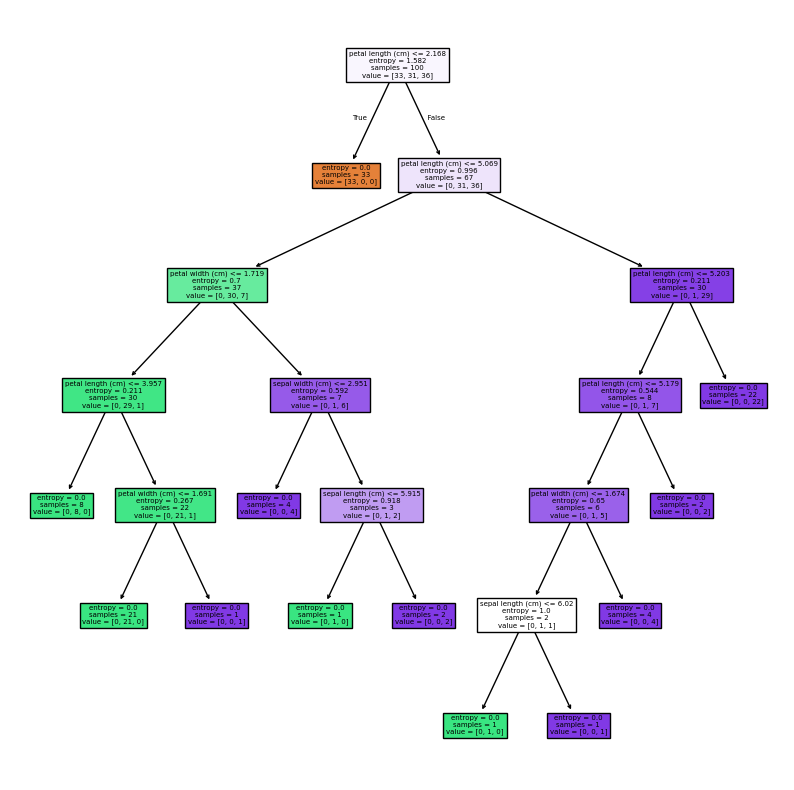

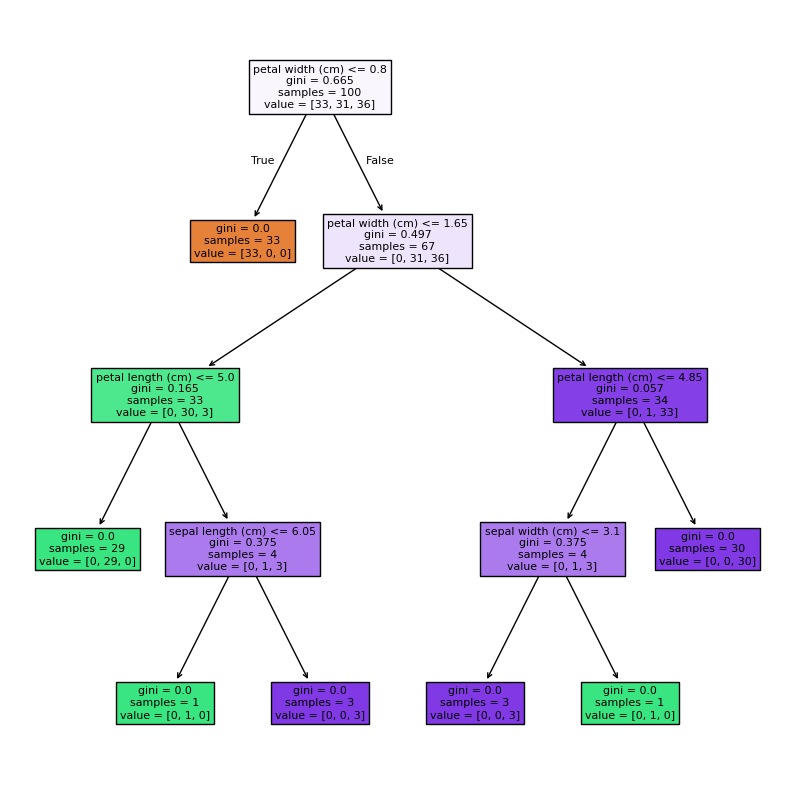

In [78]:
nom_features = iris.feature_names
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plot_tree(DTEmodel, feature_names = nom_features, filled=True)

plt.figure(figsize=(10,10))
plot_tree(DTGmodel, feature_names = nom_features, filled=True)

Quelle est son "acccuracy" sur les données d'apprentissage ?

In [ ]:
# ✍ 


TypeError: missing a required argument: 'y_pred'

Quelle est son "accuracy" sur les données de test ?

In [ ]:
# ✍ 

Comparez avec les résultats obtenus avec le classifieur bayésien.

Construisez un arbre de décision de hauteur maximale 3. Calculez le taux d'erreur apparent (sur les données d'apprentissage) et le taux d'erreur sur les données test. Comparez avec les résultats obtenus précédemment (sans limite sur la  hauteur de l'arbre)

### Arbre de Décision avec `max_depth=3`

Construisons un arbre de décision avec une hauteur maximale de 3.

In [ ]:
# ✍ 


### Comparaison avec l'arbre de décision sans limite de profondeur


 ✍ 

## k-nn (k-plus-proches-voisins) ##


Même étude mais avec les k-plus-proches-voisins

In [83]:
# ✍ 
from sklearn.neighbors import KNeighborsClassifier

KNNmodel = KNeighborsClassifier(n_neighbors=5)
KNNmodel.fit(X_test_I, y_test_I)
o_trainKNN = KNNmodel.predict(X_train_I)
o_testKNN = KNNmodel.predict(X_test_I)

### Terminez par comparer les accuracy ainsi que les rappel et précision des divers modèles que vous aurez entrainés sur la base digits.

In [ ]:
# ✍ 